# Libraries & Settings


In [1]:
import numpy as np
import pandas as pd
import scipy.linalg as la
from scipy.optimize import minimize, linprog
import matplotlib.pyplot as plt
import seaborn as sns

# Professional aesthetic setup
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', lambda x: '%.5f' % x)

print("Optimization and linear algebra environments initialized.")

Optimization and linear algebra environments initialized.


# Pairwise Comparison Matrix (PCM) Initialization


In [2]:
# Matrix calibrated for student parameters: X = 1, Y = 1
criteria = [f"Criterion {i}" for i in range(1, 5)]
n = len(criteria)

# Exact reciprocal matrix A:
# a12 = 1/X = 1.0,  a13 = (3/2)Y = 1.5, a14 = 1.0
# a21 = X = 1.0,    a23 = (3/2)X = 1.5, a24 = (1/2)Y = 0.5
# a31 = (2/3)Y,     a32 = (2/3)X,       a34 = 1/X = 1.0
# a41 = 1.0,        a42 = 2Y = 2.0,     a43 = X = 1.0
A = np.array([
    [1.00000, 1.00000, 1.50000, 1.00000],
    [1.00000, 1.00000, 1.50000, 0.50000],
    [2/3,     2/3,     1.00000, 1.00000],
    [1.00000, 2.00000, 1.00000, 1.00000]
], dtype=float)

# Reciprocity validation check
reciprocal_check = np.allclose(A * A.T, np.ones((n, n)), atol=1e-4)
print(f"Matrix is strictly reciprocal: {reciprocal_check}")

df_pcm = pd.DataFrame(A, index=criteria, columns=criteria)
df_pcm

Matrix is strictly reciprocal: True


,Criterion 1,Criterion 2,Criterion 3,Criterion 4
Criterion 1,1.00000,1.00000,1.50000,1.00000
Criterion 2,1.00000,1.00000,1.50000,0.50000
Criterion 3,0.66667,0.66667,1.00000,1.00000
Criterion 4,1.00000,2.00000,1.00000,1.00000


# Task 1 - Saaty's Principal Eigenvector & Consistency Ratio (CR)

In [3]:
def compute_eigenvector_weights(matrix):
    """
    Computes principal eigenvector, lambda_max, CI, and CR for a PCM.
    """
    n = matrix.shape[0]
    # Standard Saaty Random Consistency Index (RI)
    RI_table = {1: 0.0, 2: 0.0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41}
    
    eigenvalues, eigenvectors = la.eig(matrix)
    
    # Identify principal eigenvalue (maximum real part)
    max_idx = np.argmax(np.real(eigenvalues))
    lambda_max = np.real(eigenvalues[max_idx])
    
    # Extract corresponding eigenvector and normalize to sum = 1
    principal_ev = np.real(eigenvectors[:, max_idx])
    weights = principal_ev / np.sum(principal_ev)
    
    # Ensure all weights are positive
    if np.any(weights < 0):
        weights = -weights
        weights /= np.sum(weights)
        
    # Consistency statistics
    CI = (lambda_max - n) / (n - 1)
    RI = RI_table.get(n, 1.45)
    CR = CI / RI if RI > 0 else 0.0
    
    return weights, lambda_max, CI, CR

w_eigen, l_max, CI, CR = compute_eigenvector_weights(A)

print(f"Principal Eigenvalue (λ_max) : {l_max:.5f}")
print(f"Consistency Index (CI)       : {CI:.5f}")
print(f"Consistency Ratio (CR)       : {CR:.5f} -> {'CONSISTENT (CR < 0.1)' if CR < 0.1 else 'INCONSISTENT'}")

pd.DataFrame({"Eigenvector Weight": w_eigen}, index=criteria)

Principal Eigenvalue (λ_max) : 4.11794
Consistency Index (CI)       : 0.03931
Consistency Ratio (CR)       : 0.04368 -> CONSISTENT (CR < 0.1)


,Eigenvector Weight
Criterion 1,0.26743
Criterion 2,0.23112
Criterion 3,0.20248
Criterion 4,0.29897


# Task 2 - Classical Heuristic Approximations

In [4]:
# 1. Column Normalization & Row Arithmetic Mean (Standard Approximation)
norm_col_matrix = A / np.sum(A, axis=0)
w_arithmetic = np.mean(norm_col_matrix, axis=1)
w_arithmetic /= np.sum(w_arithmetic)

# 2. Row-Sum Normalization
w_row_sum = np.sum(A, axis=1) / np.sum(A)

# 3. Geometric Mean Method (Saaty's Logarithmic Least Squares)
geom_means = np.prod(A, axis=1) ** (1.0 / n)
w_geometric = geom_means / np.sum(geom_means)

df_approx = pd.DataFrame({
    "Exact Eigenvector": w_eigen,
    "Arithmetic Mean": w_arithmetic,
    "Geometric Mean": w_geometric,
    "Row Sum Normalization": w_row_sum
}, index=criteria)

# Error Metrics vs Exact Eigenvector (Mean Absolute Error & Euclidean Distance)
mae_metrics = {col: np.mean(np.abs(df_approx[col] - w_eigen)) for col in df_approx.columns[1:]}
dist_metrics = {col: np.linalg.norm(df_approx[col] - w_eigen) for col in df_approx.columns[1:]}

print("Approximation Error Benchmarks vs. Principal Eigenvector:")
pd.DataFrame([mae_metrics, dist_metrics], index=["MAE", "Euclidean Distance (L2)"])

Approximation Error Benchmarks vs. Principal Eigenvector:


,Arithmetic Mean,Geometric Mean,Row Sum Normalization
MAE,0.00111,0.00315,0.00325
Euclidean Distance (L2),0.00270,0.00801,0.00812


# Task 3 - Least Squares Method (LSM) Optimization Model


In [5]:
# Mathematical Formulation:
# Min  sum_{i=1}^n sum_{j=1}^n [ a_{ij} - (w_i / w_j) ]^2
# s.t. sum_{i=1}^n w_i = 1,  w_i >= 1e-4

def lsm_objective(w, matrix):
    n = len(w)
    # Ratio matrix W_ratio[i, j] = w[i] / w[j]
    W_ratio = np.outer(w, 1.0 / w)
    residuals = matrix - W_ratio
    return np.sum(residuals**2)

# Constraint: sum(w) = 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
bounds = [(1e-4, 1.0) for _ in range(n)]
w0 = np.ones(n) / n  # Uniform initial guess

res_lsm = minimize(
    fun=lsm_objective,
    x0=w0,
    args=(A,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-12, 'maxiter': 1000}
)

w_lsm = res_lsm.x
print(f"LSM Optimization Converged : {res_lsm.success}")
print(f"LSM Minimum Squared Residual: {res_lsm.fun:.6f}")

pd.DataFrame({"LSM Weight": w_lsm}, index=criteria)

LSM Optimization Converged : True
LSM Minimum Squared Residual: 1.172399


,LSM Weight
Criterion 1,0.27440
Criterion 2,0.22411
Criterion 3,0.20302
Criterion 4,0.29847


# Task 4 - Data Envelopment Analysis AHP (DEAHP) Model


In [6]:
# Each criterion i represents a DMU.
# Inputs: Constant single input = 1
# Outputs: Pairwise judgments a_{ik} for k = 1..n
# Model for DMU_i0:
# Max   sum_{k=1}^n u_k * a_{i0, k}
# s.t.  sum_{k=1}^n u_k * a_{i, k} <= 1   forall i = 1..n
#       u_k >= 1e-5

efficiency_scores = np.zeros(n)
dea_virtual_weights = np.zeros((n, n))

for dmu in range(n):
    c = -A[dmu, :]  # Objective: Maximize -> Minimize negative
    A_ub = A        # Constraints: sum(u_k * a_{ik}) <= 1
    b_ub = np.ones(n)
    bounds = [(1e-5, None) for _ in range(n)]
    
    res_dea = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    
    if res_dea.success:
        efficiency_scores[dmu] = -res_dea.fun
        dea_virtual_weights[dmu, :] = res_dea.x
    else:
        raise RuntimeError(f"DEAHP LP failed for DMU {dmu}")

# Normalized Local DEAHP Weights
w_deahp = efficiency_scores / np.sum(efficiency_scores)

df_deahp = pd.DataFrame({
    "Efficiency Score (E_i)": efficiency_scores,
    "DEAHP Normalized Weight": w_deahp
}, index=criteria)
df_deahp

,Efficiency Score (E_i),DEAHP Normalized Weight
Criterion 1,1.00000,0.25000
Criterion 2,1.00000,0.25000
Criterion 3,0.99998,0.25000
Criterion 4,1.00000,0.25000


# Task 5 - Linear Programming Method (LPM) Two-Phase Goal Programming


In [8]:
# Linear formulation for AHP weight derivation:
# w_i - a_ij * w_j - d_ij^+ + d_ij^- = 0  forall i != j
#
# Variables vector:
# [w_1, ..., w_n,  d_12^+, d_12^-, d_13^+, d_13^-, ..., d_43^+, d_43^-]
# Number of ordered pairs (i, j) with i != j is n * (n - 1) = 12
# Total variables = 4 + 2 * 12 = 28

pairs = [(i, j) for i in range(n) for j in range(n) if i != j]
n_pairs = len(pairs)
n_vars = n + 2 * n_pairs

#  PHASE 1: Minimize Total Absolute Deviations
# Objective: Min sum(d_ij^+ + d_ij^-)
c_p1 = np.zeros(n_vars)
c_p1[n:] = 1.0  # Coefficients for d+ and d-

A_eq_p1 = []
b_eq_p1 = []

# Deviation balance equations
for k, (i, j) in enumerate(pairs):
    row = np.zeros(n_vars)
    row[i] = 1.0
    row[j] = -A[i, j]
    row[n + 2*k] = -1.0      # - d_ij^+
    row[n + 2*k + 1] = 1.0   # + d_ij^-
    A_eq_p1.append(row)
    b_eq_p1.append(0.0)

# Normalization constraint: sum(w) = 1
sum_row = np.zeros(n_vars)
sum_row[:n] = 1.0
A_eq_p1.append(sum_row)
b_eq_p1.append(1.0)

A_eq_p1 = np.array(A_eq_p1)
b_eq_p1 = np.array(b_eq_p1)

var_bounds = [(1e-4, 1.0) if i < n else (0.0, None) for i in range(n_vars)]

res_p1 = linprog(c=c_p1, A_eq=A_eq_p1, b_eq=b_eq_p1, bounds=var_bounds, method='highs')
z_p1_optimal = res_p1.fun
print(f"LPM Phase 1 Minimum Inconsistency Z* = {z_p1_optimal:.6f}")

#  PHASE 2: Maximize Minimum Weight (Fair Equity)
# Maximize delta  s.t.  w_i >= delta,  Deviation_Sum <= Z* + 1e-4
# Introduce delta as variable at index 0, followed by w (1..n) and deviations.
# Total variables in Phase 2 = 1 + n_vars = 29
n_vars_p2 = 1 + n_vars
c_p2 = np.zeros(n_vars_p2)
c_p2[0] = -1.0  # Maximize delta -> Minimize -delta

# Equality constraints: exact same balance equations & sum(w) = 1
A_eq_p2 = np.zeros((A_eq_p1.shape[0], n_vars_p2))
A_eq_p2[:, 1:] = A_eq_p1
b_eq_p2 = b_eq_p1

# Inequality constraints:
# 1. w_i - delta >= 0  => -w_i + delta <= 0
# 2. Total deviations <= Z* + 1e-4
A_ub_p2 = []
b_ub_p2 = []

for i in range(n):
    row = np.zeros(n_vars_p2)
    row[0] = 1.0       # delta
    row[1 + i] = -1.0  # - w_i
    A_ub_p2.append(row)
    b_ub_p2.append(0.0)

# Deviation bound constraint
dev_bound_row = np.zeros(n_vars_p2)
dev_bound_row[1 + n:] = 1.0
A_ub_p2.append(dev_bound_row)
b_ub_p2.append(z_p1_optimal + 1e-4)

A_ub_p2 = np.array(A_ub_p2)
b_ub_p2 = np.array(b_ub_p2)

var_bounds_p2 = [(0.0, 1.0)] + [(1e-4, 1.0) if i < n else (0.0, None) for i in range(n_vars)]

res_p2 = linprog(c=c_p2, A_ub=A_ub_p2, b_ub=b_ub_p2, A_eq=A_eq_p2, b_eq=b_eq_p2, bounds=var_bounds_p2, method='highs')
w_lpm = res_p2.x[1:1+n]
w_lpm /= np.sum(w_lpm)

print(f"LPM Phase 2 Completed Successfully: {res_p2.success}")
pd.DataFrame({"LPM Weight": w_lpm}, index=criteria)

LPM Phase 1 Minimum Inconsistency Z* = 0.590909
LPM Phase 2 Completed Successfully: True


,LPM Weight
Criterion 1,0.27272
Criterion 2,0.27272
Criterion 3,0.18185
Criterion 4,0.27272


# Unified Comparison & Benchmarking of All Derived Weights

In [9]:
df_all_weights = pd.DataFrame({
    "Eigenvector (EV)": w_eigen,
    "Geometric Mean (GM)": w_geometric,
    "Arithmetic Mean (AM)": w_arithmetic,
    "Least Squares (LSM)": w_lsm,
    "DEA-AHP": w_deahp,
    "Linear Prog (LPM)": w_lpm
}, index=criteria)

# Compute performance indicators relative to the PCM
def residual_squared_error(w, matrix):
    W_ratio = np.outer(w, 1.0 / w)
    return np.sum((matrix - W_ratio)**2)

def mean_absolute_error_vs_ev(w, w_ref):
    return np.mean(np.abs(w - w_ref))

benchmark_metrics = pd.DataFrame({
    "Residual Squared Error (vs PCM)": [residual_squared_error(df_all_weights[col].values, A) for col in df_all_weights.columns],
    "Mean Absolute Deviation (vs EV)": [mean_absolute_error_vs_ev(df_all_weights[col].values, w_eigen) for col in df_all_weights.columns],
    "Max Criteria Priority": [df_all_weights[col].idxmax() for col in df_all_weights.columns]
}, index=df_all_weights.columns)

print("=== PRIORITY VECTORS DERIVED BY ALL METHODOLOGIES ===")
display(df_all_weights)

print("\n=== METHODOLOGICAL PERFORMANCE BENCHMARK ===")
display(benchmark_metrics)

=== PRIORITY VECTORS DERIVED BY ALL METHODOLOGIES ===


,Eigenvector (EV),Geometric Mean (GM),Arithmetic Mean (AM),Least Squares (LSM),DEA-AHP,Linear Prog (LPM)
Criterion 1,0.26743,0.27373,0.26818,0.27440,0.25000,0.27272
Criterion 2,0.23112,0.23018,0.23247,0.22411,0.25000,0.27272
Criterion 3,0.20248,0.20195,0.20260,0.20302,0.25000,0.18185
Criterion 4,0.29897,0.29414,0.29675,0.29847,0.25000,0.27272



=== METHODOLOGICAL PERFORMANCE BENCHMARK ===


,Residual Squared Error (vs PCM),Mean Absolute Deviation (vs EV),Max Criteria Priority
Eigenvector (EV),1.18575,0.00000,Criterion 4
Geometric Mean (GM),1.17951,0.00315,Criterion 4
Arithmetic Mean (AM),1.18753,0.00111,Criterion 4
Least Squares (LSM),1.17240,0.00375,Criterion 4
DEA-AHP,1.97216,0.03319,Criterion 1
Linear Prog (LPM),1.61067,0.02344,Criterion 1


# Visual Comparison of Priority Profiles


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2488\2491275401.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=benchmark_metrics.index, y=benchmark_metrics["Residual Squared Error (vs PCM)"], palette="viridis", ax=axes[1])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2488\2491275401.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(benchmark_metrics.index, rotation=25, ha='right')


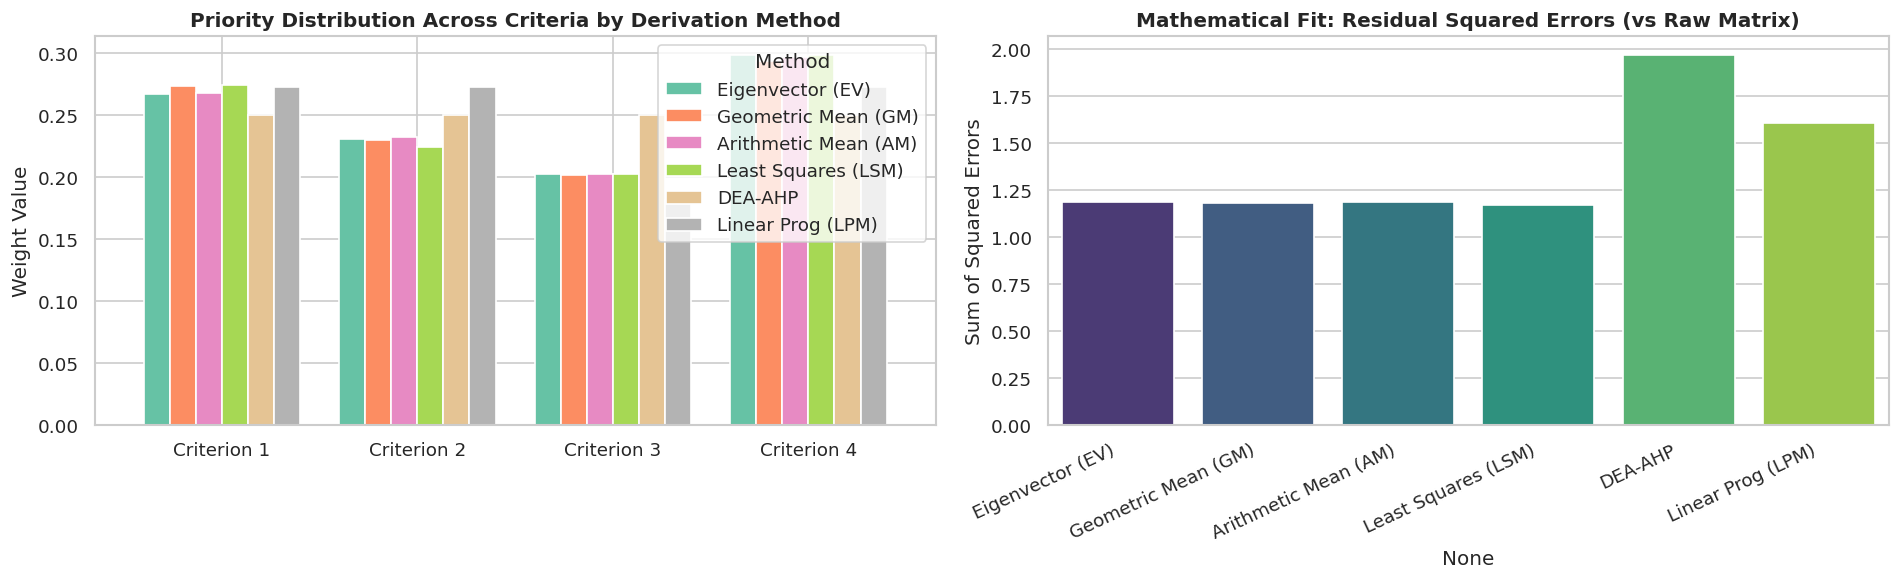

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Clustered Bar Chart
df_all_weights.plot(kind="bar", ax=axes[0], width=0.8, colormap="Set2")
axes[0].set_title("Priority Distribution Across Criteria by Derivation Method", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Weight Value")
axes[0].set_xticklabels(criteria, rotation=0)
axes[0].legend(title="Method", loc="upper right")

# 2. Residual Squared Error Comparison (Lowest is mathematically superior in least squares)
sns.barplot(x=benchmark_metrics.index, y=benchmark_metrics["Residual Squared Error (vs PCM)"], palette="viridis", ax=axes[1])
axes[1].set_title("Mathematical Fit: Residual Squared Errors (vs Raw Matrix)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Sum of Squared Errors")
axes[1].set_xticklabels(benchmark_metrics.index, rotation=25, ha='right')

plt.tight_layout()
plt.show()